Stochastic Reliability Analysis of a Data Center Power System
---

- Objective: Simulate a power system (Main Grid, Backup Generator) over time Instead of simple static failures, we model dynamic loads, component aging, random shocks, and repair cycles.
- Mathematical Goal: Calculate System Reliability R(t) and Availability A(t) with a 95% Confidence Interval.

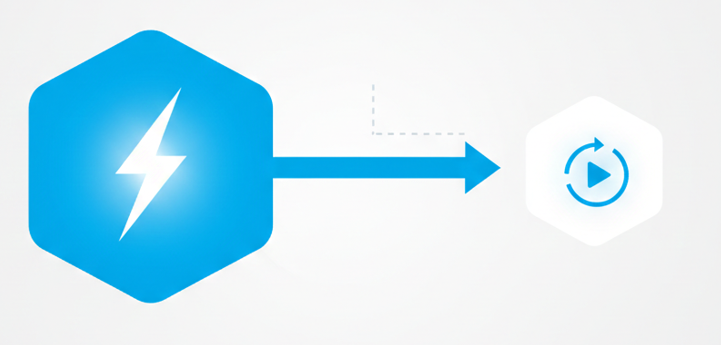

## 1. Random Number Generator (MRG32k3a)


In [1]:

import math
import time
import sys
import matplotlib.pyplot as plt
%matplotlib inline

# MRG32k3a Constants
m1=4294967087.0
a12=1403580.0
a13=-810728.0

m2=4294944443.0
a21=527612.0
a23=-1370589.0

#nitial State
mrg_s1=[12345.0,12346.0,12347.0]
mrg_s2=[12345.0,12346.0,12347.0]

def random_gen():
    global mrg_s1,mrg_s2

    # Component 1
    p1=(a12*mrg_s1[1]+a13*mrg_s1[0])%m1
    mrg_s1[0]=mrg_s1[1]
    mrg_s1[1]=mrg_s1[2]
    mrg_s1[2]=p1

    # Component 2
    p2=(a21*mrg_s2[2]+a23*mrg_s2[0])%m2
    mrg_s2[0]=mrg_s2[1]
    mrg_s2[1]=mrg_s2[2]
    mrg_s2[2]=p2

    # Combine both
    z=p1-p2
    if z<0:
        z+=m1

    return(z+1.0)/(m1+1.0)

# Validation Test
print("Validating Random Engine MRG32k3a")
test_samples=[random_gen() for _ in range(1000)]
mean_val=sum(test_samples)/len(test_samples)
print(f"Mean got from 1000 Samples: {mean_val:.4f}")


Validating Random Engine MRG32k3a
Mean got from 1000 Samples: 0.5091


## 2. Distributions



In [2]:
def normal_box_muller(mu,sigma):
    u1=random_gen()
    u2=random_gen()
    z0=math.sqrt(-2.0*math.log(u1))*math.cos(2.0*math.pi*u2)
    return mu+z0*sigma

def exponential(lambd):
    u=random_gen()
    if u==0:
        u=1e-10
    return -math.log(u)/lambd

def gamma_marsaglia_tsang(alpha,beta):
    if alpha<1:
        return gamma_marsaglia_tsang(alpha+1,beta)*(random_gen()**(1.0/alpha))

    d=alpha-1.0/3.0
    c=1.0/math.sqrt(9.0*d)

    while True:
        z=normal_box_muller(0,1)
        if z>-1.0/c:
            v=(1.0+c*z)**3
            u=random_gen()

            if u<1.0-0.0331*(z**4):
                return d*v*beta

            if math.log(u)<0.5*(z**2)+d*(1.0-v+math.log(v)):
                return d*v*beta


## 3. Power System Simulation Logic



In [3]:
#system parameters
mission_time=200.0
use_backup=True

#main component(Gamma(alfa=2,beta=50))
main_alfa=2.0
main_beta=50.0

#backup component(Exponential)
lambda_dormant=0.001
lamba_active=0.02

#repair(Normal)
repair_mu=10.0
repair_sigma=2.0

def run_system_iteration():
    #Main Component failure time
    t1=gamma_marsaglia_tsang(main_alfa,main_beta)

    if t1>mission_time:
        return False,mission_time

    if not use_backup:
        return True,t1

    #Backup Dormant Failure Check
    t2_dormant=exponential(lambda_dormant)
    if t2_dormant<t1:
        return True,t1

    #Main failed at t1, Backup takes over
    #Attempt Repair of Main
    t_repair=normal_box_muller(repair_mu,repair_sigma)

    #Backup Active Life
    t2_active=exponential(lamba_active)

    time_repair_done=t1+t_repair
    time_backup_fails=t1+t2_active

    if time_repair_done<time_backup_fails:
        return False,mission_time
    else:
        if time_backup_fails<mission_time:
            return True,time_backup_fails
        else:
            return False,mission_time


## 4. Execution Loop

In [4]:
N_iterations=10000
results_failed=[]
results_time=[]

print(f"Running Simulation ({N_iterations} iterations)...")
start_time=time.time()

for i in range(N_iterations):
    failed,t=run_system_iteration()
    results_failed.append(failed)
    results_time.append(t)

    if (i+1)%1000==0:
        sys.stdout.write(f"\rProgress:{((i+1)/N_iterations)*100:.0f}%")
        sys.stdout.flush()

elapsed=time.time()-start_time
print(f"\nSimulation completed in {elapsed:.2f} seconds.")


Running Simulation (10000 iterations)...
Progress:80%

Progress:100%
Simulation completed in 0.26 seconds.


## 5. Analysis and Visualization

Calculate statistics and plot the Reliability Curve and Convergence.

In [5]:
#summary statistics
total=len(results_failed)
failures=sum(results_failed)
pf=failures/total if total>0 else 0

#95% Confidence Interval
margin=1.96*math.sqrt((pf*(1-pf))/total) if total>1 else 0.0

print(f"System Failure Probability:   {pf:.4f}({pf*100:.2f}%)")
print(f"95% Confidence Interval:      [{pf-margin:.4f},{pf+margin:.4f}]")



System Failure Probability:   0.2205(22.05%)
95% Confidence Interval:      [0.2124,0.2286]


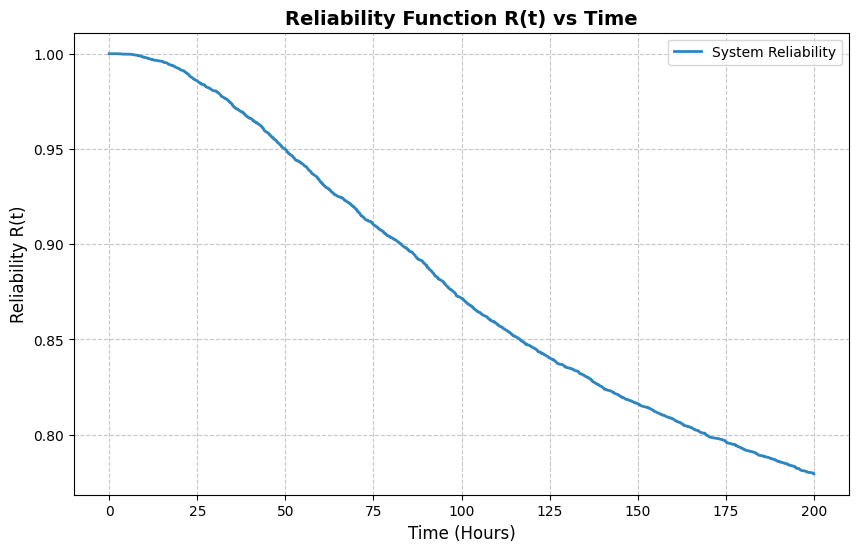

In [6]:
#Plotting the reliability curve
sorted_times=sorted(results_time)
unique_times=sorted(list(set(sorted_times)))
if unique_times and unique_times[0]>0:
    unique_times.insert(0,0.0)

reliability=[]
for t in unique_times:
    # Count survivors
    survivors=sum(1 for x in sorted_times if x>=t)
    reliability.append(survivors/total)

plt.figure(figsize=(10,6))
plt.plot(unique_times,reliability,linewidth=2,color='#2E86C1',label='System Reliability')
plt.title('Reliability Function R(t) vs Time',fontsize=14,fontweight='bold')
plt.xlabel('Time (Hours)',fontsize=12)
plt.ylabel('Reliability R(t)',fontsize=12)
plt.grid(True,linestyle='--',alpha=0.7)
plt.legend()
plt.show()


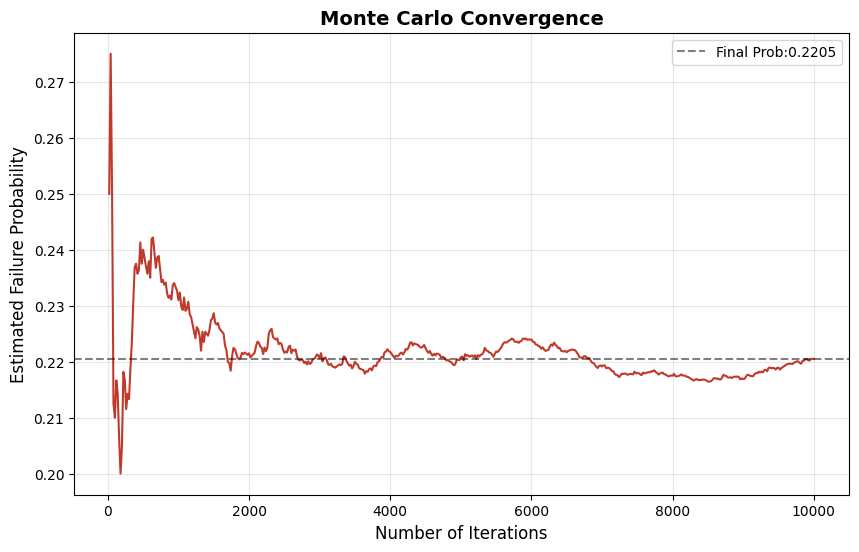

In [7]:
#plotting convergence of failure probability estimate
cumulative_failures=0
probs=[]
iterations=[]
step=max(1,total//500)

for i,failed in enumerate(results_failed):
    if failed:
        cumulative_failures+=1

    if (i+1)%step==0:
        probs.append(cumulative_failures/(i+1))
        iterations.append(i+1)

plt.figure(figsize=(10,6))
plt.plot(iterations,probs,color='#C0392B',linewidth=1.5)
plt.axhline(y=pf,color='black',linestyle='--',alpha=0.5,label=f'Final Prob:{pf:.4f}')
plt.title('Monte Carlo Convergence',fontsize=14,fontweight='bold')
plt.xlabel('Number of Iterations',fontsize=12)
plt.ylabel('Estimated Failure Probability',fontsize=12)
plt.grid(True,alpha=0.3)
plt.legend()
plt.show()
